In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("Train.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [4]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [5]:
cluster_df = df[['Cost_of_the_Product','Discount_offered']]

cluster_df.head()

,Cost_of_the_Product,Discount_offered
0,177,44
1,216,59
2,183,48
3,176,10
4,184,46


In [6]:

cluster_df = cluster_df.dropna()

print("Shape after removing null values:", cluster_df.shape)

Shape after removing null values: (10999, 2)


In [7]:

cluster_df['Cost_log'] = np.log1p(cluster_df['Cost_of_the_Product'])
cluster_df['Discount_log'] = np.log1p(cluster_df['Discount_offered'])

cluster_df[['Cost_log','Discount_log']].head()

,Cost_log,Discount_log
0,5.181784,3.806662
1,5.379897,4.094345
2,5.214936,3.891820
3,5.176150,2.397895
4,5.220356,3.850148


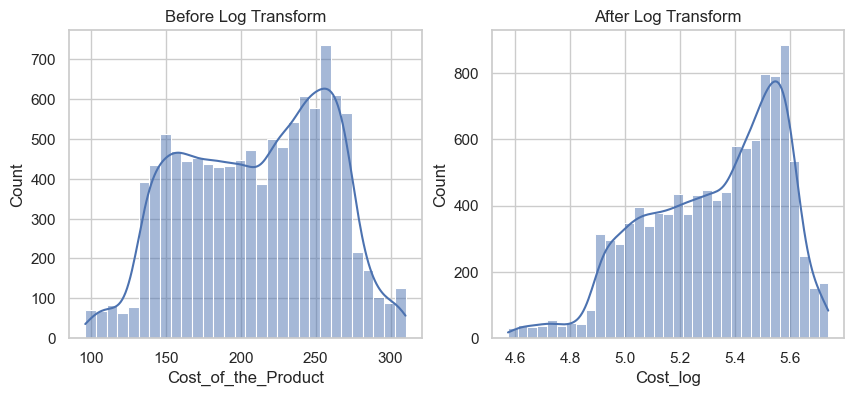

In [8]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(cluster_df['Cost_of_the_Product'], kde=True)
plt.title("Before Log Transform")

plt.subplot(1,2,2)
sns.histplot(cluster_df['Cost_log'], kde=True)
plt.title("After Log Transform")

plt.show()

In [9]:
scaler = StandardScaler()

X = scaler.fit_transform(cluster_df[['Cost_log','Discount_log']])

In [10]:
kmeans = KMeans(
        n_clusters=3,
        random_state=42,
        n_init=10
)

clusters = kmeans.fit_predict(X)

cluster_df['Cluster'] = clusters

cluster_df.head()

,Cost_of_the_Product,Discount_offered,Cost_log,Discount_log,Cluster
0,177,44,5.181784,3.806662,1
1,216,59,5.379897,4.094345,1
2,183,48,5.214936,3.891820,1
3,176,10,5.176150,2.397895,0
4,184,46,5.220356,3.850148,1


In [13]:
X = df[['Cost_of_the_Product','Weight_in_gms']]

In [14]:
X_log = np.log1p(X)

In [15]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)

In [16]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

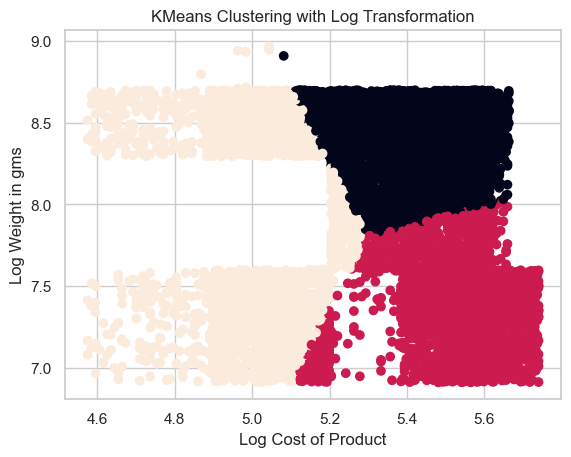

In [17]:
plt.scatter(X_log['Cost_of_the_Product'], X_log['Weight_in_gms'], c=df['Cluster'])

plt.xlabel("Log Cost of Product")
plt.ylabel("Log Weight in gms")

plt.title("KMeans Clustering with Log Transformation")

plt.show()

In [18]:
cluster_summary = df.groupby('Cluster')[['Cost_of_the_Product','Weight_in_gms']].mean()

print(cluster_summary)

         Cost_of_the_Product  Weight_in_gms
Cluster                                    
0                 224.757938    4680.582929
1                 252.656066    1673.206910
2                 150.124597    3437.395416
